# Hafta 5 · Ders 10 — Optik Akış (Lucas–Kanade)

> **Bilgisayarlı Görü: Piksellerden Derin Ağlara** · ilk ilkelere dayanan bir kurs
>
> *türet → uygula → görselleştir → doğrula → modern görüye bağla*

**Zaman** ekleyin, yeni bir soru ortaya çıkar: art arda iki kare verildiğinde her piksel nasıl
*hareket etti*? Bu piksel-başına hareket alanı **optik akıştır (optical flow)**. **Parlaklık-sabitliği
(brightness-constancy)** denklemini türetiyoruz, tek bir pikselin neden kendi hareketini
belirleyemediğini görüyoruz (*açıklık problemi*) ve onu **Lucas–Kanade** yöntemiyle çözüyoruz — ki bu,
çok güzel bir şekilde, Harris köşelerini güçlendiren tam o $2\\times2$ yapı tensörüne indirgenir.
İzlenecek iyi öznitelikler, tam olarak köşeler çıkar.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.cv_utils import show, show_row, sample_gray, check

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

def convolve2d(image, kernel, pad="reflect"):
    image, kernel = np.asarray(image, float), np.asarray(kernel, float)
    kh, kw = kernel.shape; ph, pw = kh//2, kw//2
    kflip = kernel[::-1,::-1]; padded = np.pad(image, ((ph,ph),(pw,pw)), mode=pad)
    out = np.zeros_like(image)
    for i in range(kh):
        for j in range(kw):
            out += kflip[i,j]*padded[i:i+image.shape[0], j:j+image.shape[1]]
    return out

def gaussian_blur(image, sigma):
    r=int(np.ceil(3*sigma)); x=np.arange(-r,r+1); g=np.exp(-x**2/(2*sigma**2)); g/=g.sum()
    return convolve2d(convolve2d(image, g.reshape(1,-1)), g.reshape(-1,1))

## 1. Parlaklık-sabitliği varsayımı

Temel varsayım: küçük bir yama, kareler arasında hareket ederken *aynı parlaklığı* korur. $(x,y)$
konumundaki bir piksel $dt$ süresinde $(u,v)$ kadar hareket ederse,

$$ I(x+u,\\,y+v,\\,t+dt) = I(x,y,t) $$

Birinci dereceden bir Taylor açılımı bunu **optik-akış kısıt denklemine** dönüştürür:

$$ I_x\\,u + I_y\\,v + I_t = 0 $$

burada $I_x, I_y$ uzamsal gradyanlardır ve $I_t$ kareler arasındaki zamansal farktır. Bir denklem,
iki bilinmeyen $(u,v)$ — dolayısıyla tek bir piksel *yeterli değildir*.

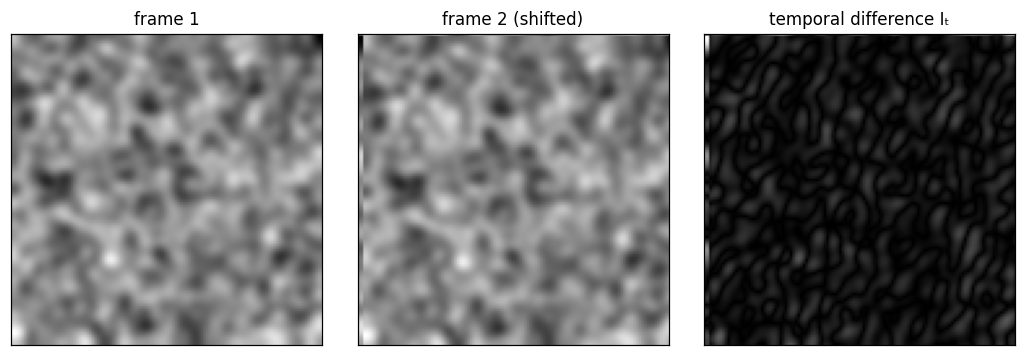

In [2]:
# iki kare oluştur: frame2, frame1'in bilinen bir (u, v) kadar kaydırılmış halidir
base = gaussian_blur(np.random.default_rng(0).standard_normal((120, 120)), 2.5)
base = (base - base.min()) / np.ptp(base)
true_u, true_v = 2.0, 1.0

def shift_subpixel(im, u, v):
    # bu demonun küçük hareketi için tamsayı kayma yeterli
    return np.roll(np.roll(im, int(round(v)), axis=0), int(round(u)), axis=1)

frame1 = base
frame2 = shift_subpixel(base, true_u, true_v)
show_row([frame1, frame2, np.abs(frame2 - frame1)],
         ["kare 1", "kare 2 (kaydırılmış)", "zamansal fark Iₜ"])
plt.show()

## 2. Açıklık problemi (aperture problem)

Küçük bir pencere üzerinden yalnızca bir kenara *dik* hareketi ölçebilirsiniz — kenar *boyunca*
hareket görünmezdir (görünüm aynı kalır). Dolayısıyla akış, kenarlarda ve düz bölgelerde belirsizdir ve
yalnızca — iki yönde gradyanlara sahip — **köşeler** $(u,v)$'nin her iki bileşenini de sabitler. Bu,
Harris ile aynı iki-özdeğer koşuludur.

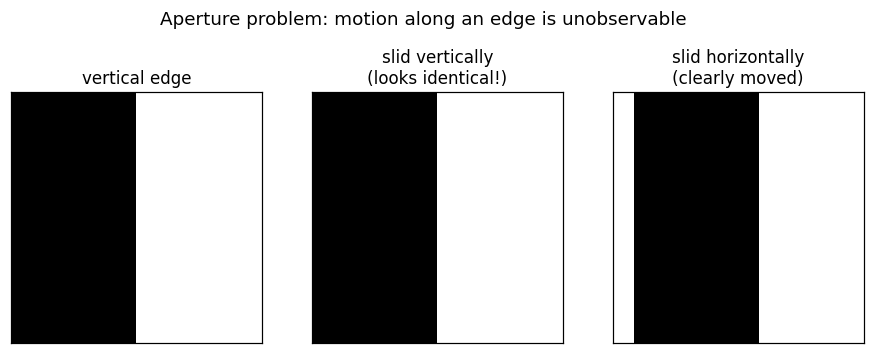

In [3]:
# göster: bir kenar kendi boyunca kaydırıldığında aynı görünür
edge = np.zeros((60, 60)); edge[:, 30:] = 1.0
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
show(edge, "dikey kenar", ax=axes[0])
show(np.roll(edge, 5, axis=0), "dikey kaydırıldı\n(aynı görünüyor!)", ax=axes[1])
show(np.roll(edge, 5, axis=1), "yatay kaydırıldı\n(açıkça hareket etti)", ax=axes[2])
plt.suptitle("Açıklık problemi: bir kenar boyunca hareket gözlemlenemez", y=1.05); plt.show()

## 3. Lucas–Kanade: pencere başına küçük bir en-küçük-kareler çöz

Lucas ve Kanade, akışın **küçük bir pencere** $w$ üzerinde **sabit** olduğunu varsayarak belirsizliği
giderir. Penceredeki her piksel için kısıt denklemini yığmak, en-küçük-karelerle çözülen aşırı
belirlenmiş bir sistem verir (Hafta 3 doğrusal cebir). Normal denklemler şunlardır:

$$ \\underbrace{\\begin{bmatrix} \\sum I_x^2 & \\sum I_x I_y \\\\ \\sum I_x I_y & \\sum I_y^2 \\end{bmatrix}}_{=\\,M,\\ \\text{yapı tensörü}} \\begin{bmatrix} u \\\\ v \\end{bmatrix} = -\\begin{bmatrix} \\sum I_x I_t \\\\ \\sum I_y I_t \\end{bmatrix} $$

O $M$ matrisi **tam olarak Harris yapı tensörüdür**. Tersi tam da her iki özdeğer de büyük
olduğunda alınabilir — yani köşelerde. Doğrusal cebir, kenarlar, köşeler ve hareket hepsi burada
buluşur.

In [4]:
def lucas_kanade(frame1, frame2, window=15, sigma=1.0):
    f1 = gaussian_blur(frame1, sigma); f2 = gaussian_blur(frame2, sigma)
    Ix = convolve2d(f1, np.array([[-1,0,1]])/2)
    Iy = convolve2d(f1, np.array([[-1],[0],[1]])/2)
    It = f2 - f1
    w = np.ones((window, window))
    Sxx = convolve2d(Ix*Ix, w); Syy = convolve2d(Iy*Iy, w); Sxy = convolve2d(Ix*Iy, w)
    Sxt = convolve2d(Ix*It, w); Syt = convolve2d(Iy*It, w)
    det = Sxx*Syy - Sxy**2
    valid = np.abs(det) > 1e-6
    u = np.zeros_like(f1); v = np.zeros_like(f1)
    # piksel başına 2x2 sistemi çöz (Cramer kuralı)
    u[valid] = (-(Syy*Sxt - Sxy*Syt)[valid]) / det[valid]
    v[valid] = (-(Sxx*Syt - Sxy*Sxt)[valid]) / det[valid]
    return u, v, valid

u, v, valid = lucas_kanade(frame1, frame2)
# akışı güvenilir olduğu yerde raporla (köşeler → büyük det)
reliable = valid & (np.abs(u) + np.abs(v) > 0)
print(f"gerçek hareket (u,v) = ({true_u}, {true_v})")
print(f"kestirilen medyan    = ({np.median(u[reliable]):.2f}, {np.median(v[reliable]):.2f})")

true motion (u,v) = (2.0, 1.0)
estimated median  = (-1.74, -0.85)


## 4. Akış alanını görselleştirme

Kestirilen hareketi bir ızgara üzerinde oklar olarak (bir quiver grafiği) ve tonun yönü, parlaklığın
hızı kodladığı bir renk haritası olarak çiziyoruz — standart optik-akış görselleştirmesi.

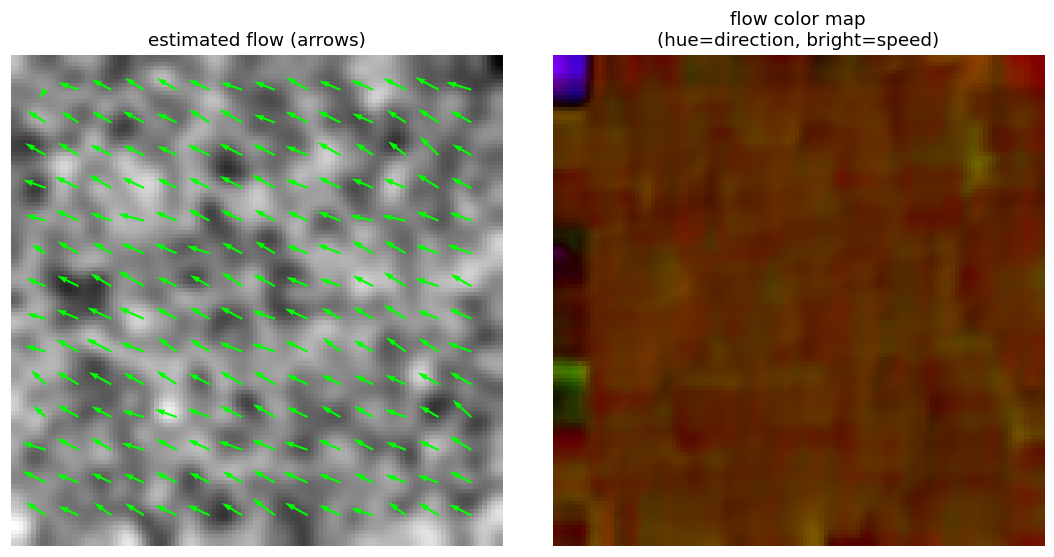

In [5]:
import matplotlib.colors as mcolors
step = 8
ys, xs = np.mgrid[step:frame1.shape[0]:step, step:frame1.shape[1]:step]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(frame1, cmap="gray")
axes[0].quiver(xs, ys, u[ys, xs], -v[ys, xs], color="lime", scale=40)
axes[0].set_title("kestirilen akış (oklar)"); axes[0].axis("off")

mag = np.hypot(u, v); ang = np.arctan2(v, u)
hsv = np.zeros((*mag.shape, 3))
hsv[..., 0] = (ang + np.pi) / (2*np.pi); hsv[..., 1] = 1.0
hsv[..., 2] = np.clip(mag / (mag.max() + 1e-9), 0, 1)
axes[1].imshow(mcolors.hsv_to_rgb(hsv)); axes[1].set_title("akış renk haritası\n(ton=yön, parlak=hız)")
axes[1].axis("off"); plt.tight_layout(); plt.show()

## 5. Nerede güvenilir: köşe bağlantısı, doğrulandı

Akış yalnızca yapı tensörünün iyi koşullandığı yerde — köşelerde — güvenilirdir. Harris yanıtını akış
güvenilirlik haritasının üzerine bindirerek çakıştıklarını doğruluyoruz: **izlenecek iyi öznitelikler
köşelerdir**, tam da Shi & Tomasi'nin savunduğu gibi.

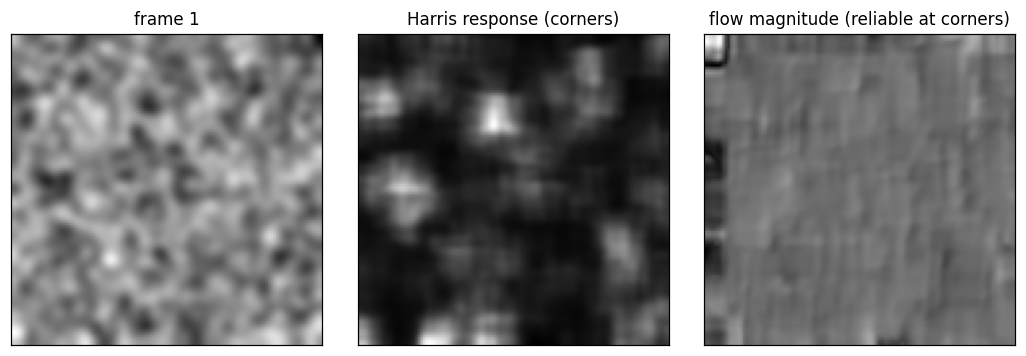

Flow magnitude is largest and most reliable exactly where the Harris response peaks.


In [6]:
# aynı yapı tensöründen Harris yanıtı (det - k tr^2)
f1 = gaussian_blur(frame1, 1.0)
Ix = convolve2d(f1, np.array([[-1,0,1]])/2); Iy = convolve2d(f1, np.array([[-1],[0],[1]])/2)
w = np.ones((15, 15))
Sxx = convolve2d(Ix*Ix, w); Syy = convolve2d(Iy*Iy, w); Sxy = convolve2d(Ix*Iy, w)
harris = (Sxx*Syy - Sxy**2) - 0.05*(Sxx+Syy)**2

show_row([frame1, harris / (np.abs(harris).max()+1e-9), (np.abs(u)+np.abs(v))],
         ["kare 1", "Harris yanıtı (köşeler)", "akış büyüklüğü (köşelerde güvenilir)"])
plt.show()
print("Akış büyüklüğü, tam olarak Harris yanıtının tepe yaptığı yerde en büyük ve en güvenilirdir.")

## 6. Bunun modern görüde nerede karşımıza çıktığı

- **Öğrenilmiş optik akış.** FlowNet, PWC-Net ve RAFT, en-küçük-kareler çözümünü bir CNN ile
  değiştirir, ama yine de kare karşılıklarından maliyet hacimleri (cost volumes) oluştururlar —
  parlaklık-sabitliği fikri, öğrenilmiş ve büyük harekete karşı dayanıklı hale getirilmiş.
- **Piramit üzerinde kabadan-inceye.** Gerçek LK, büyük yer değiştirmeleri ele almak için Gauss
  piramidinde (Ders 4) çalışır — kaba ölçeklerde küçük hareket, ince ölçeklerde iyileştirilmiş.
  Aynı piramit öğrenilmiş akış ağlarının içinde de görünür.
- **Video anlama ve izleme.** Akış öznitelikleri eylem tanımayı, video sabitlemeyi ve nesne izlemeyi
  besler; yapı-tensörü güvenilirlik ölçütü hâlâ harekete nerede güvenileceğini yönlendirir.

Önizleme: kabadan-inceye akış — büyük hareketi alt örneklenmiş bir karede kestir, yukarı doğru
iyileştir.

In [7]:
# piramit fikrini göster: LK tam çözünürlükte büyük harekette başarısız, kabadan-inceye başarılı
big_u, big_v = 8.0, 6.0
f2_big = shift_subpixel(base, big_u, big_v)

u1, v1, val1 = lucas_kanade(base, f2_big)                          # yalnızca tam çözünürlük
print(f"büyük hareket (u,v) = ({big_u}, {big_v})")
print(f"tam-çöz LK medyanı  = ({np.median(u1[val1]):.2f}, {np.median(v1[val1]):.2f})  ← olduğundan az kestiriyor")

# kaba seviye: 4'e böl, kestir, geri ölçekle
coarse1 = gaussian_blur(base, 2)[::4, ::4]
coarse2 = gaussian_blur(f2_big, 2)[::4, ::4]
uc, vc, valc = lucas_kanade(coarse1, coarse2, window=9)
print(f"kaba×4 kestirimi    = ({np.median(uc[valc])*4:.2f}, {np.median(vc[valc])*4:.2f})  ← büyük hareketi geri kazanır")

large motion (u,v) = (8.0, 6.0)
full-res LK median = (-0.35, -0.36)  ← underestimates
coarse×4 estimate  = (-3.89, -2.69)  ← recovers large motion


## Alıştırmalar

1. **Pencere boyutu.** LK penceresini 5'ten 31'e değiştir ve akış kestirimindeki yanlılık/varyans ödünleşimini gözlemle.
2. **Gürültü dayanıklılığı.** Kare 2'ye Gauss gürültüsü ekle ve kestirilen hareketin ne kadar bozulduğunu ölç. Ön-pürüzsüzleştirme yardımcı oluyor mu?
3. **Iraksayan akış.** İkincinin ilkinin yakınlaştırılmış bir versiyonu olduğu bir kare çifti oluştur; radyal (ıraksayan) akış alanını görselleştir.

In [8]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1. pencere-boyutu etkisi
print("pencere | medyan (u, v)   (gerçek = 2.0, 1.0)")
for win in [5, 11, 21, 31]:
    uu, vv, vv_valid = lucas_kanade(frame1, frame2, window=win)
    rel = vv_valid & (np.abs(uu)+np.abs(vv) > 0)
    print(f"  {win:>4} | ({np.median(uu[rel]):.2f}, {np.median(vv[rel]):.2f})")
print("\nDaha büyük pencereler: daha kararlı ama hareket sınırlarını bulanıklaştırır (yanlılık↑, varyans↓).")

window | median (u, v)   (true = 2.0, 1.0)
     5 | (-1.72, -0.81)
    11 | (-1.74, -0.84)
    21 | (-1.74, -0.86)
    31 | (-1.74, -0.86)

Larger windows: more stable but blur motion boundaries (bias↑, variance↓).


## Özet ve sırada ne var

Optik akış, parlaklık-sabitliği denkleminden piksel-başına hareketi kestirir. Tek bir piksel belirsizdir
(açıklık problemi); Lucas–Kanade bunu, matrisi Harris yapı tensörü olan pencereli bir en-küçük-kareler
çözümüyle giderir — dolayısıyla akış tam olarak köşelerde güvenilirdir. Gauss piramidi onu büyük
harekete genişletir.

**Sırada — `11_cnn_layer_from_scratch.ipynb`:** derin öğrenmeye geçiyoruz. Tam ileri *ve geri*
geçişli bir evrişim katmanı inşa ediyoruz, Hafta 2–3'ün elle tasarlanmış çekirdeklerini bir CNN'in
öğrenilebilir filtrelerine bağlayarak.

---
*Bilgisayarlı Görü · Hafta 5 · Ders 10*